# Marketplace Customer Analytics

## Regional Analysis

This notebook visualizes regional customer and order statistics
obtained from the SQL analysis of marketplace data.

The analysis compares:
- customer base size;
- total number of orders;
- average order value (AOV);
- installment usage;
- promo code usage;
- customer cancellation rate.

The underlying SQL query is available in:

`../sql/adhoc03_regional_statistics.sql`

In [1]:
import pandas as pd
import plotly.express as px

In [2]:
df = pd.read_csv("regional_statistics.csv")

df

,region,total_users_region,orders_total_region,aov_region,installments_ratio,promo_ratio,cancel_ratio
0,Москва,39386,40747,3140.14,0.48,0.037,0.0063
1,Санкт-Петербург,11978,12414,3593.46,0.55,0.042,0.0053
2,Новосибирская область,11044,11401,3491.79,0.54,0.037,0.0043


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               3 non-null      str    
 1   total_users_region   3 non-null      int64  
 2   orders_total_region  3 non-null      int64  
 3   aov_region           3 non-null      float64
 4   installments_ratio   3 non-null      float64
 5   promo_ratio          3 non-null      float64
 6   cancel_ratio         3 non-null      float64
dtypes: float64(4), int64(2), str(1)
memory usage: 300.0 bytes


In [4]:
df.isna().sum()

region                 0
total_users_region     0
orders_total_region    0
aov_region             0
installments_ratio     0
promo_ratio            0
cancel_ratio           0
dtype: int64

In [5]:
fig = px.bar(
    df.sort_values("total_users_region", ascending=True),
    x="total_users_region",
    y="region",
    orientation="h",
    title="Customer Base by Region",
    labels={
        "total_users_region": "Number of Customers",
        "region": "Region"
    },
    text="total_users_region"
)

fig.update_traces(textposition="outside")

fig.show()

In [8]:
fig.write_html("customer_segmentation.html")

In [26]:
fig = px.bar(
    df.sort_values("aov_region", ascending=True),
    x="aov_region",
    y="region",
    orientation="h",
    title="Average Order Value (AOV) by Region",
    labels={
        "aov_region": "Average Order Value",
        "region": "Region"
    },
    text="aov_region"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

fig.show()

In [22]:
fig = px.bar(
    df.sort_values("installments_ratio", ascending=True),
    x="installments_ratio",
    y="region",
    orientation="h",
    title="Installment Usage by Region",
    labels={
        "installments_ratio": "Share of Orders with Installments",
        "region": "Region"
    },
    text="installments_ratio"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="inside"
)

fig.show()

In [27]:
fig = px.bar(
    df.sort_values("promo_ratio", ascending=True),
    x="promo_ratio",
    y="region",
    orientation="h",
    title="Promo Code Usage by Region",
    labels={
        "promo_ratio": "Share of Orders with Promo Code",
        "region": "Region"
    },
    text="promo_ratio"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="inside"
)

fig.show()

In [24]:
fig = px.bar(
    df.sort_values("cancel_ratio", ascending=True),
    x="cancel_ratio",
    y="region",
    orientation="h",
    title="Customer Cancellation Rate by Region",
    labels={
        "cancel_ratio": "Share of Customers with Cancelled Orders",
        "region": "Region"
    },
    text="cancel_ratio"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="inside"
)

fig.show()

In [25]:
df.sort_values("total_users_region", ascending=False)

,region,total_users_region,orders_total_region,aov_region,installments_ratio,promo_ratio,cancel_ratio
0,Москва,39386,40747,3140.14,0.48,0.037,0.0063
1,Санкт-Петербург,11978,12414,3593.46,0.55,0.042,0.0053
2,Новосибирская область,11044,11401,3491.79,0.54,0.037,0.0043


## Key Findings

- Moscow has the largest customer base and the highest total number of orders among the analyzed regions.
- Saint Petersburg has the highest average order value (AOV) at 3,593.46 and the highest share of orders paid in installments at 55%.
- Novosibirsk region has a similar AOV to Saint Petersburg, while Moscow has a lower average order value despite having the largest customer base.
- Promo code usage is relatively similar across regions, ranging from 3.7% to 4.2%.
- Moscow has the highest customer cancellation rate at 0.63%, although cancellation rates remain low across all analyzed regions.

## Customer Activity by First Order Cohort

In [28]:
import pandas as pd

cohort_df = pd.read_csv(
    "first_order_cohort_analysis.csv"
)

cohort_df.head()

,month_of_2023,users_in_month,orders_in_month,aov_month,avg_order_rating_month,money_transfer_ratio_month,avg_customer_activity_duration
0,2023-01-01,465,499,2865.79,4.18,0.21,12 days 19:37:09.617205
1,2023-02-01,1063,1115,2556.01,4.17,0.22,7 days 00:47:00.06397
2,2023-03-01,1663,1762,2764.68,4.20,0.21,8 days 03:58:47.521346
3,2023-04-01,1435,1511,3144.97,4.15,0.19,7 days 01:58:58.324739
4,2023-05-01,2197,2322,2775.32,4.22,0.20,7 days 16:51:16.78152


In [29]:
cohort_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   month_of_2023                   12 non-null     str    
 1   users_in_month                  12 non-null     int64  
 2   orders_in_month                 12 non-null     int64  
 3   aov_month                       12 non-null     float64
 4   avg_order_rating_month          12 non-null     float64
 5   money_transfer_ratio_month      12 non-null     float64
 6   avg_customer_activity_duration  12 non-null     str    
dtypes: float64(3), int64(2), str(2)
memory usage: 804.0 bytes


In [30]:
cohort_df["month_of_2023"] = pd.to_datetime(
    cohort_df["month_of_2023"]
)

In [34]:
cohort_df["month_label"] = cohort_df[
    "month_of_2023"
].dt.strftime("%b")

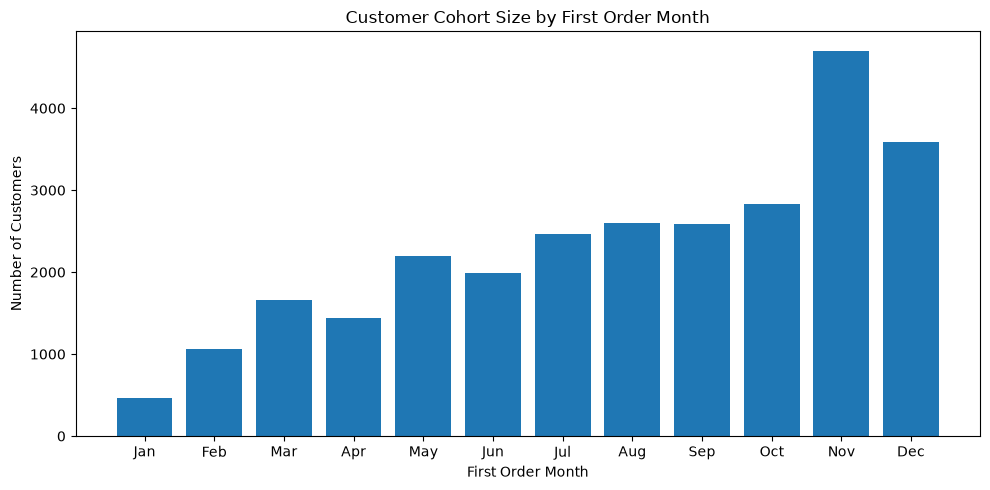

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    cohort_df["month_label"],
    cohort_df["users_in_month"]
)

plt.title("Customer Cohort Size by First Order Month")
plt.xlabel("First Order Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Interpretation

The size of customer cohorts varies substantially throughout 2023.
The January cohort is the smallest, while the November cohort is the largest,
indicating significant variation in customer acquisition dynamics across the year.

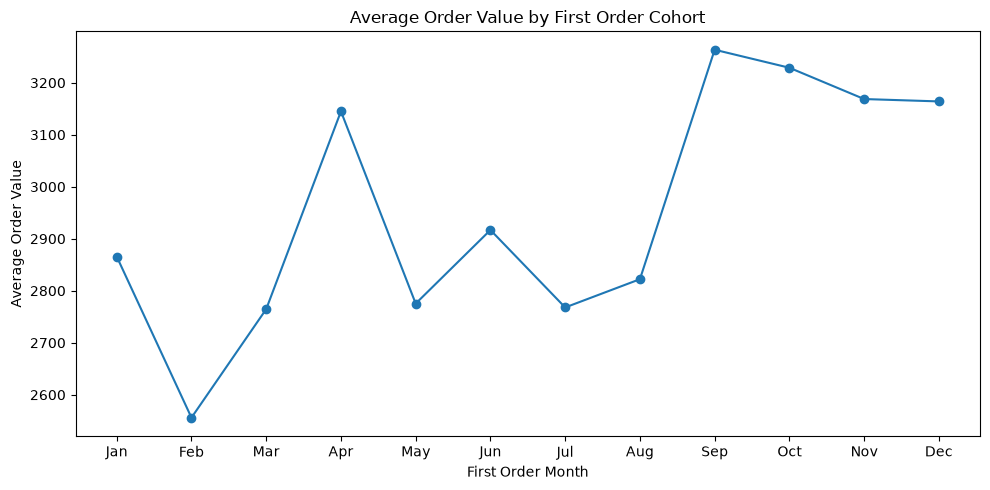

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    cohort_df["month_label"],
    cohort_df["aov_month"],
    marker="o"
)

plt.title("Average Order Value by First Order Cohort")
plt.xlabel("First Order Month")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

### Interpretation

Average order value varies across first-order cohorts.
The September cohort has the highest average order value,
while the February cohort has the lowest.
The observed differences may reflect seasonal variation
in purchasing behavior and customer composition.

In [38]:
cohort_df["avg_customer_activity_duration"] = pd.to_timedelta(
    cohort_df["avg_customer_activity_duration"]
)

In [39]:
cohort_df["activity_duration_days"] = (
    cohort_df["avg_customer_activity_duration"]
    .dt.total_seconds()
    / 86400
)

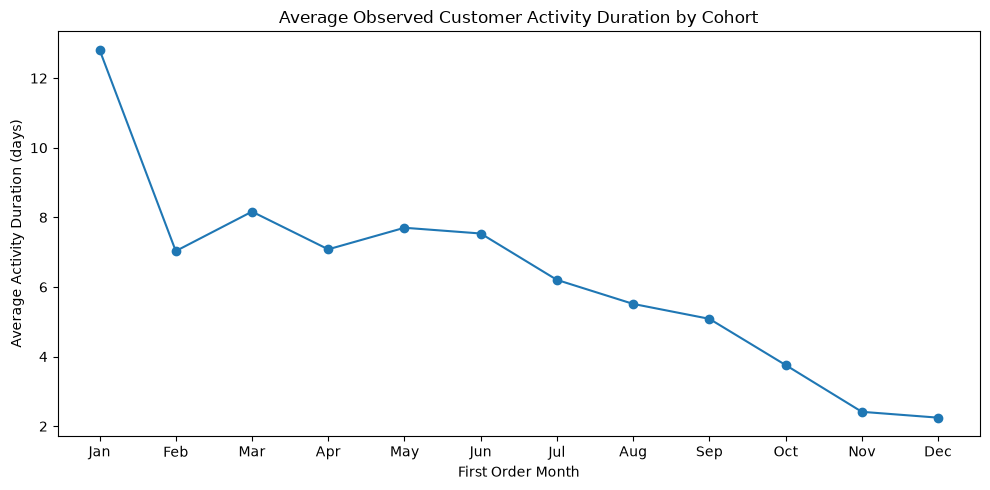

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    cohort_df["month_label"],
    cohort_df["activity_duration_days"],
    marker="o"
)

plt.title("Average Observed Customer Activity Duration by Cohort")
plt.xlabel("First Order Month")
plt.ylabel("Average Activity Duration (days)")

plt.tight_layout()
plt.show()

### Interpretation

The average observed customer activity duration decreases substantially
for later first-order cohorts. This pattern should be interpreted with caution,
as customers acquired later in 2023 have a shorter available observation window
in the dataset.

Therefore, the observed decline should not be interpreted directly as evidence
of lower customer retention among later cohorts without controlling for
the unequal observation period.

## Overall Cohort Analysis Summary

The cohort analysis reveals substantial variation in customer acquisition
and purchasing behavior throughout 2023.

The size of first-order cohorts varies considerably, with the largest cohort
observed in November and the smallest in January. Average order value also
differs across cohorts, with the September cohort showing the highest AOV.

The share of customers using money transfers remains relatively stable
across cohorts.

Later cohorts show shorter observed customer activity duration. However,
this result should be interpreted cautiously because later cohorts have
a shorter observation window in the available data. Further retention analysis
with a fixed observation horizon would be required to compare cohort retention
fairly.